# CS383: Data Science and Machine Learning  
## Lecture 1 — How Machines Learn from Data

*Dr. Thitima Srivatanakul*

### Guiding question
**How can a machine learn to recognize patterns from examples?**

### Learning objectives
By the end of this lecture, you should be able to:

- explain the difference between data science and machine learning;
- identify data, features, labels, training data, and test data;
- describe how a classifier learns from labeled examples;
- explain why more or better training data can improve predictions;
- identify basic data types and summarize a small dataset;
- use Jupyter notebooks to run Python code and complete short exercises.

---

### Course approach
This course is practical and project-based. We will repeatedly follow this workflow:

**Problem → Data → Explore → Model → Evaluate → Improve → Communicate**


*Live in-class version — this lecture is unplugged, so there is nothing to type along with; run the opening demo together and follow the activity as a class.*

---

### Before we start: a 60-second preview

Everything after this point in this lecture is unplugged — no coding. But before we build intuition for *how* a machine learns, here's a glimpse of where the semester is headed.

The cell below reaches out to NYC's live public Open Data platform, pulls thousands of real 311 service requests filed by real New Yorkers, and turns them into an answer in about the time it takes to read this sentence. You don't need to understand the code yet — just run the cell and watch.

Ref: https://data.cityofnewyork.us/Social-Services/311-Service-Requests-from-2020-to-Present/erm2-nwe9/about_data

No live connection right now — showing a saved sample of 10,000 311-style requests instead.


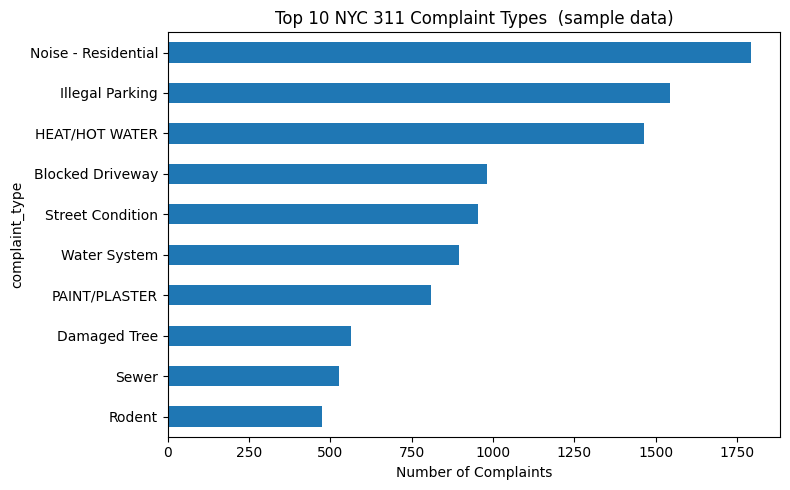

In [ ]:
# A live preview — no need to understand every line yet.
# We will build the skills to write code like this ourselves by Week 4.

import pandas as pd
import matplotlib.pyplot as plt
import requests

SOCRATA_URL = "https://data.cityofnewyork.us/resource/erm2-nwe9.json"

try:
    response = requests.get(
        SOCRATA_URL,
        params={
            "$limit": 10000,
            "$order": "created_date DESC",
            "$select": "complaint_type,borough,created_date",
        },
        timeout=8,
    )
    response.raise_for_status()
    complaints = pd.DataFrame(response.json())
    live = True
except Exception:
    # Offline fallback, in case there is no internet connection in the room.
    import numpy as np
    rng = np.random.default_rng(383)
    complaint_types = ["Noise - Residential", "Illegal Parking", "HEAT/HOT WATER",
                        "Blocked Driveway", "Street Condition", "Water System",
                        "PAINT/PLASTER", "Damaged Tree", "Sewer", "Rodent"]
    boroughs = ["MANHATTAN", "BROOKLYN", "QUEENS", "BRONX", "STATEN ISLAND"]
    complaints = pd.DataFrame({
        "complaint_type": rng.choice(
            complaint_types, size=10000,
            p=[0.18, 0.15, 0.14, 0.10, 0.10, 0.09, 0.08, 0.06, 0.05, 0.05],
        ),
        "borough": rng.choice(boroughs, size=10000, p=[0.22, 0.32, 0.26, 0.16, 0.04]),
    })
    live = False

if live:
    print(f"Loaded {len(complaints):,} real NYC 311 requests, pulled live just now.")
    print(f"Most recent: {complaints['created_date'].max()}  |  Oldest in this batch: {complaints['created_date'].min()}")
else:
    print(f"No live connection right now — showing a saved sample of {len(complaints):,} 311-style requests instead.")

top10 = complaints["complaint_type"].value_counts().head(10)

plt.figure(figsize=(8, 5))
top10.sort_values().plot(kind="barh")
plt.title("Top 10 NYC 311 Complaint Types" + ("  (live data)" if live else "  (sample data)"))
plt.xlabel("Number of Complaints")
plt.tight_layout()
plt.show()

### What just happened?

In about a dozen lines of code we:

1. pulled real records from a live government database;
2. counted how often each complaint type occurs;
3. turned that into a chart anyone could read in five seconds.

This is the entire spine of the course: **real data → wrangle it → explore it → communicate the pattern.** By Week 4 you'll be writing SQL queries against a database like this one yourself. By Week 5 you'll be turning charts like this into a full report for a non-technical audience.

For the rest of this lecture, we're going unplugged — no code — to build intuition for *how* a machine learns from labeled examples in the first place.

---

### How Machines Learn — Unplugged

This portion is unplugged — no coding. We build intuition for how machine learning works before writing a single line of Python.


## Part 1 — Unplugged Activity: You Are the Machine

Your task is to learn how to recognize the Thai character:

# บ

You do **not** need to know Thai. Treat each character as a visual pattern.

You will be shown labeled examples such as:

- **Correct**: the character is บ
- **Incorrect**: the character is not บ

Some incorrect examples may look very similar, such as:

- ข
- ป
- ช

### Round 1
Study a small set of labeled examples.

Then answer:

1. What visual features seem important?
2. What rule are you using?
3. How confident are you?
4. Which examples are difficult?

### Round 2
Classify new, unseen examples as:

- **บ**
- **Not บ**

### Round 3
After receiving more labeled examples, classify another test set.

Record whether your accuracy improves.


### Open the activity

Go to this page now and follow along as your instructor reveals each labeled example:

**[Open the Thai Character Activity](https://thitimas.github.io/cs383-fa26-materials-public/lect01/thai_character_activity.html)**

The page walks through Rounds 1–3 itself (training examples, then a quiz after each round with your accuracy) — use the worksheet below to record your answers as you go.

### Activity worksheet

Complete this table during the activity.

| Observation | Your response |
|---|---|
| Features I noticed | |
| My first classification rule | |
| Most confusing character | |
| Accuracy in Round 1 | |
| What changed after more training examples? | |
| Accuracy in Round 2 | |

### Discussion questions

- Did everyone use the same features?
- Did more examples help?
- Did any examples make your rule fail?
- What would happen if some labels were wrong?
- Could a machine make the same kinds of mistakes?


## Part 2 — Connecting the Activity to Machine Learning

| What happened in the activity | Machine learning term |
|---|---|
| Thai characters | Data |
| A collection of characters | Dataset |
| Correct / Incorrect | Labels |
| Shape, height, loops, openings | Features |
| Labeled examples used for learning | Training data |
| New examples used for checking performance | Test data |
| Your internal decision rule | Model |
| Your answer for a new character | Prediction |
| Correct or incorrect prediction | Evaluation |
| Percentage correct | Accuracy |
| A wrong prediction | Error |
| Improving after more examples | Learning from data |

### Key idea

> A machine learning model learns patterns from examples and uses those patterns to make predictions about new data.


## Part 3 — Data Science vs. Machine Learning

### Data Science
Data science is the broader process of working with data to:

- collect and organize it;
- clean and explore it;
- visualize patterns;
- build models;
- interpret and communicate results.

### Machine Learning
Machine learning is one tool within data science. It focuses on learning patterns from data to make predictions or decisions.

### In this activity

- collecting the characters = **data collection**
- labeling them = **data preparation**
- looking for visual patterns = **exploratory analysis**
- deciding what features matter = **feature engineering**
- creating a rule = **model building**
- checking new characters = **testing**
- counting mistakes = **evaluation**


## Part 4 — The Data Science Workflow

We will use this workflow throughout the semester:

1. **Define the problem**
2. **Collect or obtain data**
3. **Clean and prepare the data**
4. **Explore and visualize the data**
5. **Build a model**
6. **Evaluate the model**
7. **Improve the model**
8. **Communicate the findings**

### Reflection
Which steps did we already complete during the Thai character activity?


---

### Before Continuing

Before moving to the next part of this lecture, please do this:

- Confirm you can open and run this course notebook in our course environment (check the LMS announcement for access details).
- Skim the Key Terms list near the end of this notebook — we'll start using this vocabulary right away.


---

### The Big Picture of Data Science and ML

Now we zoom out from the activity you just completed. Still no coding — we'll build the conceptual foundation the rest of the semester stands on: what data science and ML actually look like in practice, the workflow that ties every project together, the two big families of ML problems, and the basic types of data you'll be wrangling starting in Lecture 3.

Python and NumPy start next lecture. This part of the lecture is about the ideas.

## Part 5 — Recap: What We Learned So Far

Before moving on, connect the earlier activity to what's next.

- You built an internal "model" that classified บ vs. not-บ using **labeled examples** — that's supervised learning.
- Your accuracy changed as you saw more (and harder) training examples.
- We mapped the activity onto vocabulary: data, features, labels, training data, test data, model, prediction, accuracy.

### Quick discussion
- In your own words, what made a character "hard to classify"?
- Would your rule for spotting บ have worked on a character you never saw during training? Why or why not?

## Part 6 — What Is Data Science and ML, Really?

Earlier, we defined data science and machine learning in the abstract. Now, let's ground that in things you already use.

### Spot the ML
For each of the following, discuss with a neighbor: is this **definitely ML**, **maybe just rules/logic**, or **not sure**?

- A streaming service recommending what to watch next
- A spam filter deciding whether an email is junk
- A voice assistant understanding what you said
- A bank flagging a transaction as possibly fraudulent
- A traffic light that changes every 60 seconds
- A photo app that recognizes faces in your pictures
- An ATM checking your PIN is correct

### The pattern
Machine learning tends to show up when:

- the rules would be too complicated or numerous to write by hand;
- the task involves recognizing patterns in messy, real-world data (images, text, behavior);
- more data existing over time should make the system better.

Rules-based software (the ATM PIN check, the fixed traffic light) doesn't need ML — a simple, fixed rule is enough and is more predictable.

### Why this matters for your career
Every "definitely ML" example above is built by teams doing the exact workflow we introduced earlier,
using the exact skills this course is built around: wrangling messy data, evaluating models honestly, and
communicating results to people who didn't build the model.

## Part 7 — The Data Science Workflow, Applied

Earlier we listed the 8-step workflow as words on a page. Let's walk it end-to-end using a real,
concrete example: the same NYC 311 data from the earlier live pull.

**Scenario:** The city wants to know which complaint types take the longest to resolve, so they can staff accordingly.

| Step | Applied to this scenario |
|---|---|
| 1. Define the problem | Can we predict how long a new complaint will take to resolve, based on its type, borough, and time filed? |
| 2. Collect data | Pull 311 service requests from NYC Open Data (you saw this live earlier in the lecture) |
| 3. Clean the data | Missing boroughs, duplicate complaint reports, inconsistent complaint-type spelling over the years |
| 4. Explore the data | Which complaint types are most common? (the bar chart from earlier) Do certain boroughs have longer resolution times? |
| 5. Build a model | Train a model that predicts resolution time from complaint type, borough, and time of year (Weeks 6–11) |
| 6. Evaluate the model | How far off are the model's predictions, on average, on complaints it hasn't seen? |
| 7. Improve the model | Add more features (weather? day of week?), try a different model type |
| 8. Communicate | Report findings to city staffing managers who don't know what a model is, only what it means for their team |

### Discussion
- Which step do you think takes the most real-world time and effort for a working data scientist? (Hint: it's almost never step 5.)
- Which of these 8 steps have we, as a class, already done — even without writing code?

## Part 8 — Supervised vs. Unsupervised Learning

The Thai character activity earlier had an answer key: every example was labeled Correct or Incorrect
before you saw it. That's **supervised learning** — learning a rule from labeled examples.

This next activity has no answer key at all.

### Open the activity

**[Open the Unsupervised Sorting Activity](https://thitimas.github.io/cs383-fa26-materials-public/lect01/unsupervised_sorting_activity.html)**

Drag the 16 city objects into whatever groups make sense to you. There's no correct number of groups, and
no one will tell you if you're "right." Only once you're done should you click through to see three
different, equally valid ways to group the very same 16 objects.

### Activity worksheet

| Observation | Your response |
|---|---|
| How many groups did I make? | |
| What feature(s) did I group by? | |
| Which of the three reveal groupings (color / object type / size) matched mine? | |
| Did my neighbor group differently than me? | |

### Supervised vs. Unsupervised, side by side

| | Supervised Learning | Unsupervised Learning |
|---|---|---|
| Labels given? | Yes — every training example has a known answer | No — no labels at all |
| Goal | Learn a rule to predict the label of new examples | Find structure or groups in the data |
| Earlier activity | Thai character classification | — |
| This activity | — | Sorting city objects |
| Real-world example | Spam detection, price prediction, fraud detection | Customer segmentation, anomaly detection, topic discovery |
| Course coverage | Weeks 6–11 (regression, classification, trees) | Week 12 (clustering, PCA) |

### Key idea
> Unsupervised learning doesn't have a "correct" grouping to check against — only more or less *useful* groupings, depending on what question you're trying to answer.

## Part 9 — Types of Data

Before we start wrangling real datasets in Lecture 3 onward, you need a working vocabulary for the *kinds* of columns you'll encounter.

### Numerical data
- **Continuous**: can take any value in a range (temperature, exam score, resolution time in hours)
- **Discrete**: countable whole numbers (number of complaints, number of bedrooms)

### Categorical data
- **Nominal**: categories with no natural order (borough, complaint type, color)
- **Ordinal**: categories with a natural order (satisfaction rating: low/medium/high; letter grade: A/B/C/D/F)

### Structured vs. unstructured
- **Structured**: fits neatly into rows and columns (a spreadsheet, a database table)
- **Unstructured**: doesn't (free-text complaint descriptions, photos, audio)

### The gotcha
A `zip_code` column is made of digits, but it is **categorical**, not numerical — the average of two zip
codes means nothing, and 10002 is not "twice as much" as 05001. Whether a column is numerical or
categorical depends on whether *doing math on it makes sense*, not on whether it looks like a number.

### Quick exercise
For each column below (all real fields in the NYC 311 dataset from earlier in this lecture), classify it as
**numerical (continuous/discrete)** or **categorical (nominal/ordinal)**:

1. `complaint_type` (e.g., "Illegal Parking")
2. `incident_zip`
3. `resolution_time_hours`
4. `borough`
5. `created_date`

**Your answers:**

1.  
2.  
3.  
4.  
5.  

## Part 10 — Key Terms

- **Data**: information collected for analysis.
- **Dataset**: an organized collection of data.
- **Observation**: one row or example.
- **Feature**: an input variable used by a model.
- **Label / Target**: the outcome to be predicted.
- **Training data**: examples used to teach a model.
- **Test data**: separate examples used to evaluate a model.
- **Model**: a learned relationship or decision rule.
- **Prediction**: a model's output for new data.
- **Supervised learning**: learning from labeled examples (the Thai character activity).
- **Unsupervised learning**: finding structure in data with no labels given (the sorting activity).
- **Cluster**: a group formed by an unsupervised algorithm based on similarity.
- **Classification**: predicting a category (a supervised task).
- **Regression**: predicting a numerical value (a supervised task) — starting Week 6.
- **Numerical data**: continuous or discrete quantities that can be measured or counted.
- **Categorical data**: nominal (unordered) or ordinal (ordered) categories.
- **Structured / unstructured data**: neatly tabular vs. free-form (text, images, audio).
- **Accuracy**: the proportion of correct predictions.
- **EDA**: exploring data using summaries and visualizations — starting Week 5.
- **Outlier**: a value unusually far from the rest of the data.

---

**Exercises for this lecture**

The Exit Ticket and Optional Challenge for this lecture live in a separate notebook: `lect01_intro_to_ds_ml_exercise.ipynb`.